In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("theblackmamba31/landscape-image-colorization")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/theblackmamba31/landscape-image-colorization


In [3]:
!pip install torch.utils

  Preparing metadata (setup.py) ... done
  Created wheel for torch.utils: filename=torch_utils-0.1.2-py3-none-any.whl size=6188 sha256=898e5adc94590b8721820b79a19e1582033986b2bc5ba4515f41f9cee690fe67
  Stored in directory: /root/.cache/pip/wheels/4e/06/32/1d26da91e30177d171ecb60995273ad8709ca2b6ce66ccefa7
Successfully built torch.utils


In [1]:
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from skimage.color import rgb2lab, lab2rgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Cihaz:', DEVICE)

Cihaz: cuda


In [2]:
IMG_SIZE   = 256
BATCH_SIZE = 32

all_paths = sorted(glob.glob('//kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/color/**/*.jpg', recursive=True) +
                   glob.glob('/kaggle/input/datasets/theblackmamba31/landscape-image-colorization/landscape Images/color/**/*.png', recursive=True))
random.seed(42)
random.shuffle(all_paths)

n = len(all_paths)
train_paths = all_paths[:int(n * 0.8)]
val_paths   = all_paths[int(n * 0.8):int(n * 0.9)]
test_paths  = all_paths[int(n * 0.9):]
print(f'Eğitim: {len(train_paths)}  |  Val: {len(val_paths)}  |  Test: {len(test_paths)}')


class ColorizationDataset(Dataset):

    def __init__(self, paths):
        self.paths = paths
        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img    = Image.open(self.paths[idx]).convert('RGB')
        img    = self.transform(img)                        
        img_np = img.permute(1, 2, 0).numpy()             
        lab    = rgb2lab(img_np).astype(np.float32)        

        L  = torch.from_numpy(lab[:, :, 0:1] / 100.0).permute(2, 0, 1) 
        AB = torch.from_numpy(lab[:, :, 1:]  / 128.0).permute(2, 0, 1) 
        return L, AB


train_dl = DataLoader(ColorizationDataset(train_paths), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_dl   = DataLoader(ColorizationDataset(val_paths),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dl  = DataLoader(ColorizationDataset(test_paths),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Eğitim: 5703  |  Val: 713  |  Test: 713


In [3]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        
        self.encoder = nn.Sequential(
            nn.Conv2d(1,   32,  kernel_size=3, stride=2, padding=1), nn.ReLU(),  
            nn.Conv2d(32,  64,  kernel_size=3, stride=2, padding=1), nn.ReLU(),  
            nn.Conv2d(64,  128, kernel_size=3, stride=2, padding=1), nn.ReLU(),  
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1), nn.ReLU(), 
        )

        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), nn.ReLU(),  
            nn.ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1), nn.ReLU(),  
            nn.ConvTranspose2d(64,  32,  kernel_size=4, stride=2, padding=1), nn.ReLU(), 
            nn.ConvTranspose2d(32,  2,   kernel_size=4, stride=2, padding=1), nn.Tanh(),  
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


model  = Autoencoder().to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f'Toplam parametre: {params:,}')

ornek_giris  = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
ornek_cikis  = model(ornek_giris)
print(f'Giriş : {tuple(ornek_giris.shape)}')
print(f'Çıkış : {tuple(ornek_cikis.shape)}')

Toplam parametre: 1,077,218
Giriş : (1, 1, 256, 256)
Çıkış : (1, 2, 256, 256)


In [12]:
!pip install torch

In [7]:
EPOCHS    = 300
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

best_val_loss = float('inf')
history = {'train': [], 'val': []}

for epoch in range(1, EPOCHS + 1):


    model.train()
    train_loss = 0
    for L, AB in train_dl:
        L, AB = L.to(DEVICE), AB.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(L), AB)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * L.size(0)
    train_loss /= len(train_dl.dataset)

    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for L, AB in val_dl:
            L, AB = L.to(DEVICE), AB.to(DEVICE)
            val_loss += criterion(model(L), AB).item() * L.size(0)
    val_loss /= len(val_dl.dataset)

    history['train'].append(train_loss)
    history['val'].append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'Epoch {epoch:3d}  Train: {train_loss:.5f}  Val: {val_loss:.5f}  kaydedildi')
    elif epoch % 10 == 0:
        print(f'Epoch {epoch:3d}  Train: {train_loss:.5f}  Val: {val_loss:.5f}')

print(f'Eğitim bitti! En iyi val loss: {best_val_loss:.5f}')

Epoch   1  Train: 0.01184  Val: 0.01082  ✅ kaydedildi
Epoch   2  Train: 0.01036  Val: 0.00993  ✅ kaydedildi
Epoch   3  Train: 0.00953  Val: 0.00953  ✅ kaydedildi
Epoch   4  Train: 0.00919  Val: 0.00887  ✅ kaydedildi
Epoch   6  Train: 0.00879  Val: 0.00867  ✅ kaydedildi
Epoch   8  Train: 0.00859  Val: 0.00841  ✅ kaydedildi
Epoch  10  Train: 0.00842  Val: 0.00840  ✅ kaydedildi
Epoch  12  Train: 0.00827  Val: 0.00818  ✅ kaydedildi
Epoch  17  Train: 0.00798  Val: 0.00807  ✅ kaydedildi
Epoch  20  Train: 0.00781  Val: 0.00796  ✅ kaydedildi
Epoch  22  Train: 0.00766  Val: 0.00790  ✅ kaydedildi
Epoch  23  Train: 0.00775  Val: 0.00783  ✅ kaydedildi
Epoch  30  Train: 0.00702  Val: 0.00782  ✅ kaydedildi
Epoch  33  Train: 0.00688  Val: 0.00781  ✅ kaydedildi
Epoch  40  Train: 0.00636  Val: 0.00795
Epoch  50  Train: 0.00597  Val: 0.00802
Epoch  60  Train: 0.00580  Val: 0.00811
Epoch  70  Train: 0.00574  Val: 0.00812
Epoch  80  Train: 0.00573  Val: 0.00812
Epoch  90  Train: 0.00572  Val: 0.00812
Epoc

KeyboardInterrupt: 

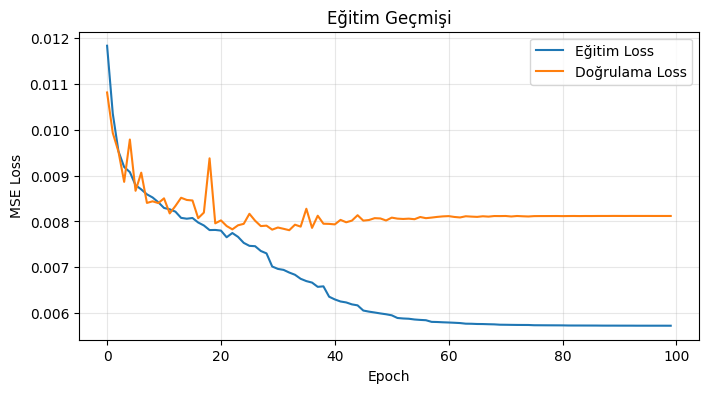

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history['train'], label='Eğitim Loss')
plt.plot(history['val'],   label='Doğrulama Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Eğitim Geçmişi')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

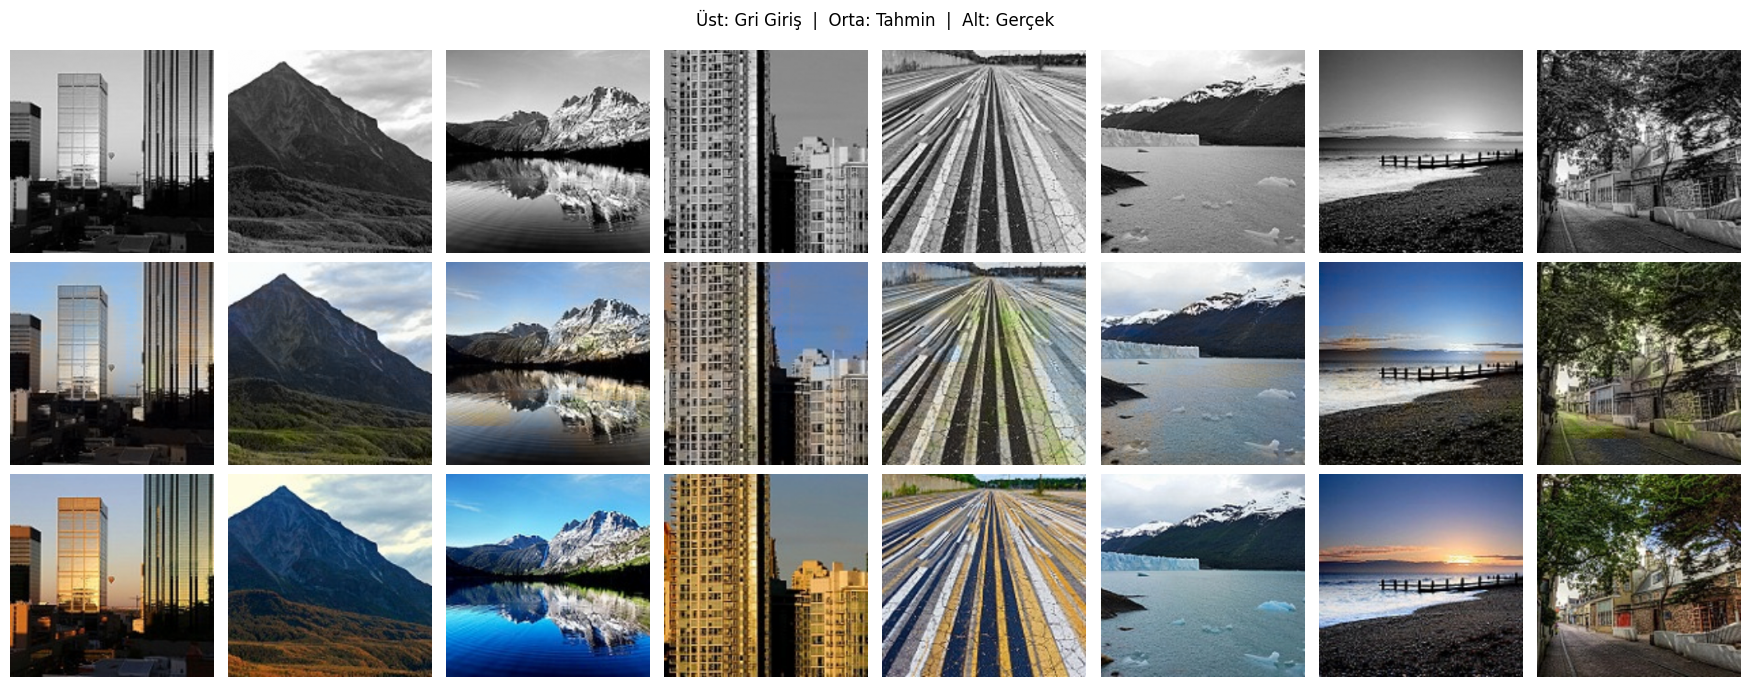

In [4]:

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = Autoencoder().to(DEVICE)

model.load_state_dict(torch.load('/kaggle/input/models/abdulsametsaba/hayata-renk-kat/pytorch/default/1/best_model.pth', map_location=DEVICE))
model.eval()

def lab_to_rgb(L, AB):
    L_np  = L.squeeze().numpy() * 100.0
    AB_np = AB.permute(1, 2, 0).numpy() * 128.0
    lab   = np.concatenate([L_np[:, :, None], AB_np], axis=-1)
    return (lab2rgb(lab) * 255).clip(0, 255).astype(np.uint8)

L_batch, AB_batch = next(iter(test_dl))
with torch.no_grad():
    pred_batch = model(L_batch.to(DEVICE)).cpu()

n = 8
fig, axes = plt.subplots(3, n, figsize=(n * 2.2, 7))
fig.suptitle('Üst: Gri Giriş  |  Orta: Tahmin  |  Alt: Gerçek', fontsize=12)

for i in range(n):
    axes[0, i].imshow(L_batch[i].squeeze(), cmap='gray')
    axes[1, i].imshow(lab_to_rgb(L_batch[i], pred_batch[i]))
    axes[2, i].imshow(lab_to_rgb(L_batch[i], AB_batch[i]))
    for row in range(3):
        axes[row, i].axis('off')

plt.tight_layout()
plt.show()

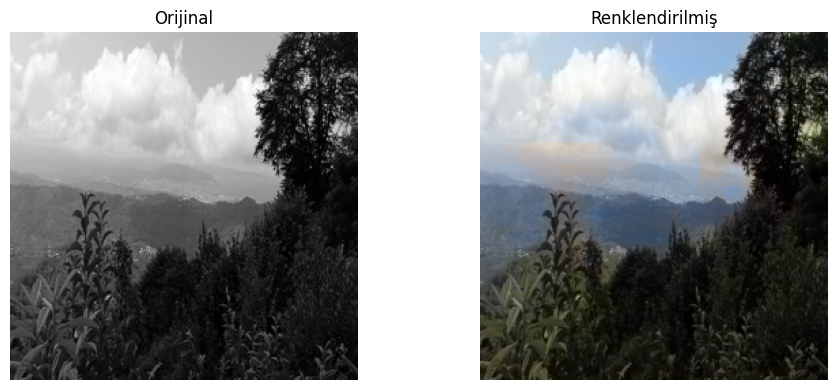

In [5]:

img_name ="/kaggle/input/datasets/abdulsametsaba/deneme-1/monokrom-fotoraflari.jpg"

img    = Image.open(img_name).convert('RGB')
tf     = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])
img_t  = tf(img)
lab    = rgb2lab(img_t.permute(1, 2, 0).numpy()).astype(np.float32)
L_t    = torch.from_numpy(lab[:, :, 0:1] / 100.0).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    AB_pred = model(L_t).squeeze(0).cpu()

result = lab_to_rgb(L_t.squeeze(0).cpu(), AB_pred)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img.resize((IMG_SIZE, IMG_SIZE))); ax[0].set_title('Orijinal');        ax[0].axis('off')
ax[1].imshow(result);                          ax[1].set_title('Renklendirilmiş'); ax[1].axis('off')
plt.tight_layout()
plt.show()

Image.fromarray(result).save('renklendirilmis.png')